# Clasificador de Landmarks — Transfer Learning
**Proyecto Final · Módulo 6 Deep Learning · UCB**

Pipeline: DataLoaders → ResNet50 (Feature Extraction + Fine-Tuning) → EfficientNet-B0 → Comparación → predict_landmarks

In [6]:
%matplotlib inline
import os
import multiprocessing
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from livelossplot import PlotLosses

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, SubsetRandomSampler

from sklearn.metrics import confusion_matrix
from PIL import Image

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.11.0+cu130


In [7]:
# Device — patron del curso (cifar10_cnn_solution.ipynb)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    print(f"Training on GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Training on CPU.")

# Paths
BASE_DIR   = Path(".")
TRAIN_DIR  = BASE_DIR / "train"
TEST_DIR   = BASE_DIR / "test"
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

# Hiperparametros
batch_size  = 64
valid_size  = 0.2
num_workers = min(4, multiprocessing.cpu_count())
NUM_CLASSES = 50
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f"batch_size={batch_size} | num_workers={num_workers}")

Training on GPU: NVIDIA GeForce RTX 5060 Ti
batch_size=64 | num_workers=4


## Transformaciones y DataLoaders

In [8]:
train_transform = T.Compose([
    T.Resize(256),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.RandAugment(num_ops=2, magnitude=9),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transformaciones definidas.")

Transformaciones definidas.


In [9]:
def get_data_loaders(train_dir, test_dir, batch_size, valid_size=0.2,
                     train_transform=None, eval_transform=None, num_workers=4):
    """Patron identico a cifar10_cnn_solution.ipynb del curso."""
    train_full = ImageFolder(train_dir, transform=train_transform)
    test_data  = ImageFolder(test_dir,  transform=eval_transform)

    n_tot   = len(train_full)
    split   = int(np.floor(valid_size * n_tot))
    indices = torch.randperm(n_tot)
    train_idx, valid_idx = indices[split:], indices[:split]

    valid_full = ImageFolder(train_dir, transform=eval_transform)

    loaders = {
        "train": DataLoader(train_full, batch_size=batch_size,
                            sampler=SubsetRandomSampler(train_idx),
                            num_workers=num_workers),
        "valid": DataLoader(valid_full, batch_size=batch_size,
                            sampler=SubsetRandomSampler(valid_idx),
                            num_workers=num_workers),
        "test":  DataLoader(test_data, batch_size=batch_size,
                            shuffle=False, num_workers=num_workers),
    }
    return loaders, train_full.classes


data_loaders, class_names = get_data_loaders(
    str(TRAIN_DIR), str(TEST_DIR),
    batch_size=batch_size,
    valid_size=valid_size,
    train_transform=train_transform,
    eval_transform=eval_transform,
    num_workers=num_workers,
)
print(f"DataLoaders listos — clases: {len(class_names)}")

DataLoaders listos — clases: 50


## Funciones de Entrenamiento

Patrón idéntico al notebook `cifar10_cnn_solution.ipynb` del curso con barras de progreso `tqdm`.

In [5]:
def compute_accuracy(dataloader, model, device):
    """Calcula accuracy en un dataloader (sin gradientes)."""
    model.eval()
    model.to(device)
    correct, total = 0, 0
    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)
            pred = model(data).max(1, keepdim=True)[1]
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += data.size(0)
    return correct / total


def train_one_epoch(train_dataloader, model, optimizer, loss, device):
    model.to(device)
    model.train()
    train_loss = 0.0

    for batch_idx, (data, target) in tqdm(
        enumerate(train_dataloader), desc="Training",
        total=len(train_dataloader), leave=True, ncols=80
    ):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss_value = loss(output, target)
        loss_value.backward()
        optimizer.step()
        train_loss = train_loss + (
            (1 / (batch_idx + 1)) * (loss_value.data.item() - train_loss)
        )

    return train_loss


def valid_one_epoch(valid_dataloader, model, loss, device):
    with torch.no_grad():
        model.eval()
        model.to(device)
        valid_loss = 0.0

        for batch_idx, (data, target) in tqdm(
            enumerate(valid_dataloader), desc="Validating",
            total=len(valid_dataloader), leave=True, ncols=80
        ):
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss_value = loss(output, target)
            valid_loss = valid_loss + (
                (1 / (batch_idx + 1)) * (loss_value.data.item() - valid_loss)
            )

    return valid_loss


def optimize(data_loaders, model, optimizer, loss, n_epochs, save_path,
             interactive_tracking=False, device=None):
    """Loop de entrenamiento con Early Stopping, ReduceLROnPlateau y livelossplot opcional."""
    if interactive_tracking:
        liveloss = PlotLosses()

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.1, patience=5, threshold=0.01
    )

    valid_loss_min = None
    logs = {}
    train_loss_hist, valid_loss_hist = [], []
    train_acc_hist,  valid_acc_hist  = [], []

    for epoch in range(1, n_epochs + 1):
        train_loss = train_one_epoch(data_loaders["train"], model, optimizer, loss, device)
        valid_loss = valid_one_epoch(data_loaders["valid"], model, loss, device)
        train_acc  = compute_accuracy(data_loaders["train"], model, device)
        valid_acc  = compute_accuracy(data_loaders["valid"], model, device)

        train_loss_hist.append(train_loss)
        valid_loss_hist.append(valid_loss)
        train_acc_hist.append(train_acc)
        valid_acc_hist.append(valid_acc)

        print(
            "Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}".format(
                epoch, train_loss, valid_loss
            )
        )

        if valid_loss_min is None or (
            (valid_loss_min - valid_loss) / valid_loss_min > 0.01
        ):
            print(f"New minimum validation loss: {valid_loss:.6f}. Saving model ...")
            torch.save(model.state_dict(), save_path)
            valid_loss_min = valid_loss

        if interactive_tracking:
            logs["loss"]     = train_loss
            logs["val_loss"] = valid_loss
            liveloss.update(logs)
            liveloss.send()

        scheduler.step(valid_loss)

    return train_loss_hist, valid_loss_hist, train_acc_hist, valid_acc_hist


def one_epoch_test(test_dataloader, model, loss, device):
    test_loss = 0.
    correct   = 0.
    total     = 0.

    with torch.no_grad():
        model.eval()
        model.to(device)
        preds   = []
        actuals = []

        for batch_idx, (data, target) in tqdm(
            enumerate(test_dataloader), desc='Testing',
            total=len(test_dataloader), leave=True, ncols=80
        ):
            data, target = data.to(device), target.to(device)
            logits     = model(data)
            loss_value = loss(logits, target).detach()
            test_loss  = test_loss + (
                (1 / (batch_idx + 1)) * (loss_value.data.item() - test_loss)
            )

            pred = logits.data.max(1, keepdim=True)[1]
            correct += torch.sum(
                torch.squeeze(pred.eq(target.data.view_as(pred))).cpu()
            )
            total += data.size(0)

            preds.extend(pred.data.cpu().numpy().squeeze())
            actuals.extend(target.data.view_as(pred).cpu().numpy().squeeze())

    print('Test Loss: {:.6f}\n'.format(test_loss))
    print('\nTest Accuracy: %2d%% (%2d/%2d)' % (
        100. * correct / total, correct, total
    ))
    return test_loss, preds, actuals


def plot_training_curves(train_loss, valid_loss, train_acc, valid_acc, title=""):
    """Grafica curvas de loss y accuracy (train vs validation) — rúbrica Fases 2 y 3."""
    epochs = range(1, len(train_loss) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    if title:
        fig.suptitle(title, fontsize=14, fontweight="bold")

    axes[0].plot(epochs, train_loss, "b-o", label="Train Loss", markersize=3)
    axes[0].plot(epochs, valid_loss, "r-o", label="Valid Loss", markersize=3)
    axes[0].set_title("Curvas de Pérdida")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, [a * 100 for a in train_acc], "b-o", label="Train Accuracy", markersize=3)
    axes[1].plot(epochs, [a * 100 for a in valid_acc], "r-o", label="Valid Accuracy", markersize=3)
    axes[1].set_title("Curvas de Accuracy")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# Loss compartida para todos los modelos TL
loss_fn = nn.CrossEntropyLoss()

print("Funciones de entrenamiento definidas.")

Funciones de entrenamiento definidas.


## Fase 3: Transfer Learning
*(Rúbrica: 7 puntos — 2 modelos preentrenados, justificación, entrenamiento, comparación, TorchScript)*

---

## Modelo 1: ResNet50

**Justificación:** ResNet50 es el modelo de referencia en `transfer_learning_solution.ipynb` del curso. Sus 25M parámetros y residual connections permiten gradientes estables en fine-tuning. Preentrenado en ImageNet (1.2M imágenes, 1000 clases).

**Estrategia 2 fases:**
1. Fase 1 — Congelar backbone, entrenar solo cabeza (20 épocas, lr=1e-3)
2. Fase 2 — Fine-tuning completo (20 épocas, lr=1e-5)

In [6]:
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Reemplazar capa final para 50 clases
n_features_resnet = resnet50.fc.in_features   # 2048
resnet50.fc = nn.Linear(n_features_resnet, NUM_CLASSES)

# Congelar backbone
frozen_params_resnet = []
for name, param in resnet50.named_parameters():
    if "fc" not in name:
        param.requires_grad = False
        frozen_params_resnet.append(param)

params_total     = sum(p.numel() for p in resnet50.parameters())
params_trainable = sum(p.numel() for p in resnet50.parameters() if p.requires_grad)
print(f"ResNet50 — Parámetros totales:    {params_total:,}")
print(f"ResNet50 — Parámetros entrenables: {params_trainable:,}  (solo fc)")

ResNet50 — Parámetros totales:    23,610,482
ResNet50 — Parámetros entrenables: 102,450  (solo fc)


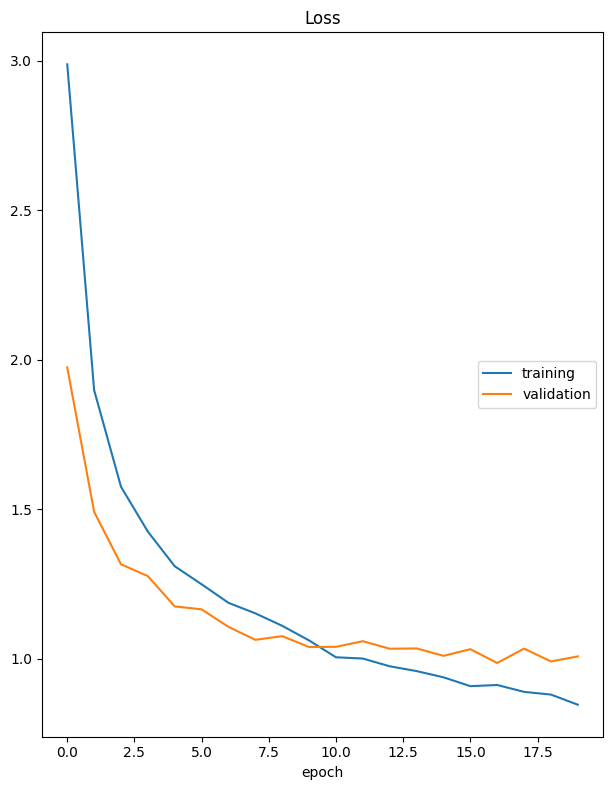

Loss
	training         	 (min:    0.847, max:    2.987, cur:    0.847)
	validation       	 (min:    0.986, max:    1.974, cur:    1.008)


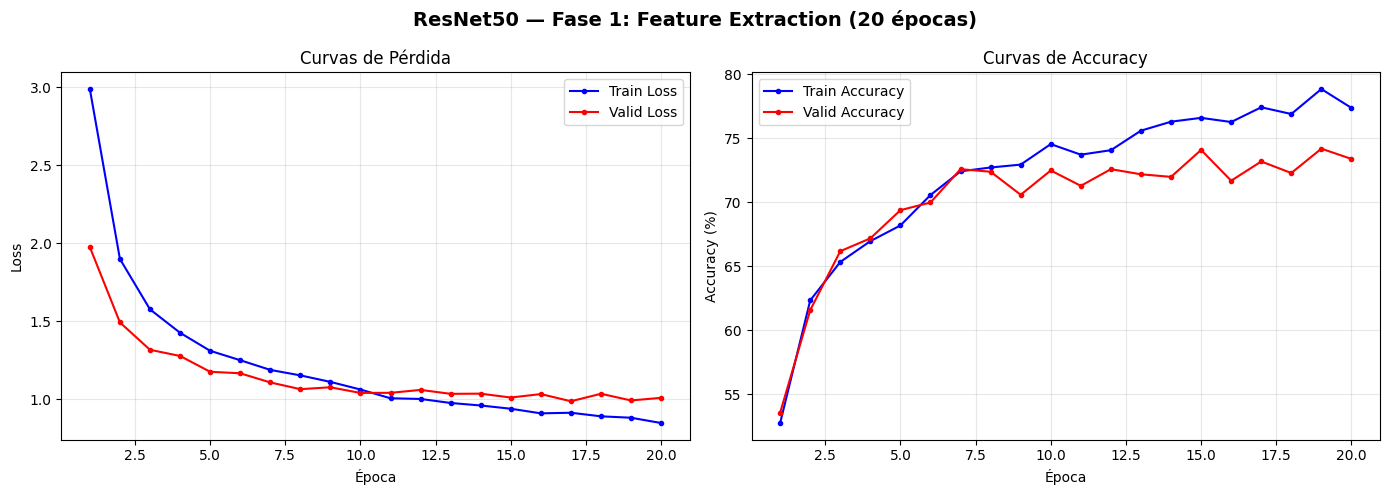

In [7]:
# Fase 1: Entrenar solo la cabeza (20 épocas)
optimizer_r50_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, resnet50.parameters()), lr=1e-3
)
SAVE_PATH_R50 = str(MODELS_DIR / "resnet50_best.pt")

print("=== Fase 1: Cabeza ResNet50 (20 epocas) ===")
hist_r50_p1 = optimize(
    data_loaders=data_loaders,
    model=resnet50,
    optimizer=optimizer_r50_p1,
    loss=loss_fn,
    n_epochs=20,
    save_path=SAVE_PATH_R50,
    interactive_tracking=True,
    device=device,
)
plot_training_curves(*hist_r50_p1, title="ResNet50 — Fase 1: Feature Extraction (20 épocas)")

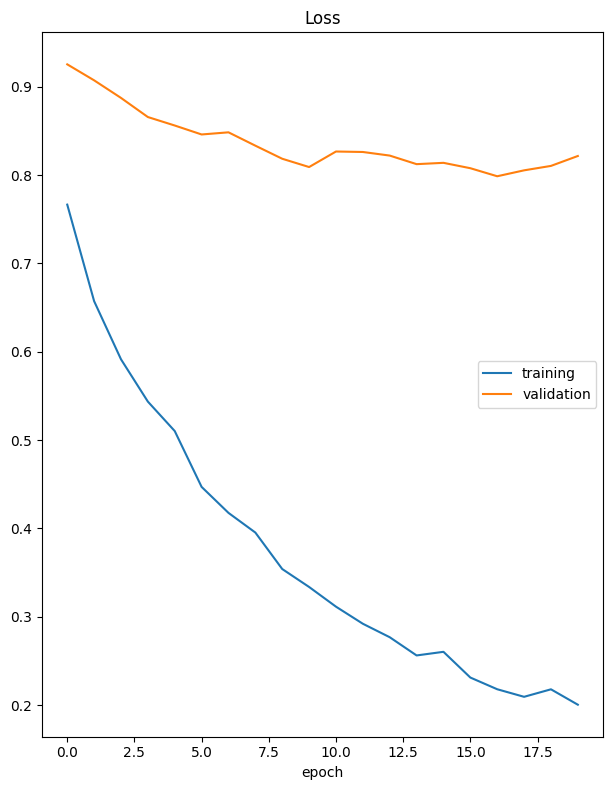

Loss
	training         	 (min:    0.201, max:    0.766, cur:    0.201)
	validation       	 (min:    0.799, max:    0.925, cur:    0.822)


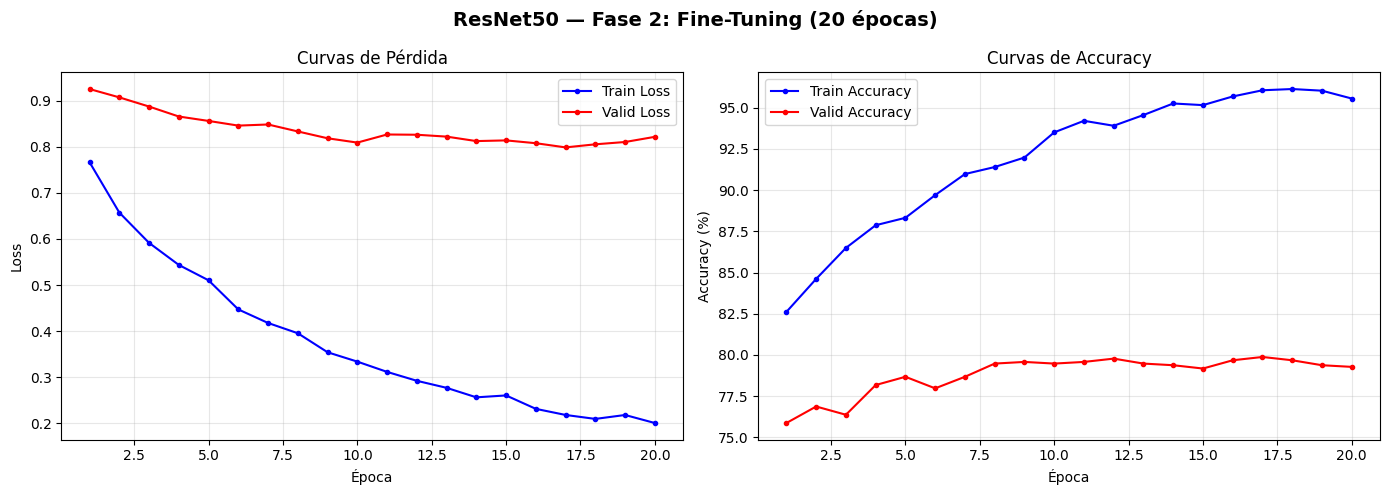

In [8]:
# Fase 2: Fine-tuning completo (20 épocas, lr=1e-5)
for param in frozen_params_resnet:
    param.requires_grad = True

optimizer_r50_p2 = optim.Adam(resnet50.parameters(), lr=1e-5)

print("=== Fase 2: Fine-tuning ResNet50 (20 epocas, lr=1e-5) ===")
hist_r50_p2 = optimize(
    data_loaders=data_loaders,
    model=resnet50,
    optimizer=optimizer_r50_p2,
    loss=loss_fn,
    n_epochs=20,
    save_path=SAVE_PATH_R50,
    interactive_tracking=True,
    device=device,
)
plot_training_curves(*hist_r50_p2, title="ResNet50 — Fase 2: Fine-Tuning (20 épocas)")

In [9]:
# Evaluación ResNet50
resnet50.load_state_dict(torch.load(SAVE_PATH_R50, map_location=device))
print("=== Evaluación ResNet50 en Test ===")
test_loss_r50, preds_r50, actuals_r50 = one_epoch_test(data_loaders["test"], resnet50, loss_fn, device)
acc_r50 = sum(p == a for p, a in zip(preds_r50, actuals_r50)) / len(actuals_r50)
print(f"ResNet50 Test Accuracy: {acc_r50:.2%}")

=== Evaluación ResNet50 en Test ===


Testing: 100%|██████████████████████████████████| 20/20 [00:10<00:00,  1.98it/s]

Test Loss: 0.634183


Test Accuracy: 83% (1045/1250)
ResNet50 Test Accuracy: 83.60%


---

## Modelo 2: EfficientNet-B0

**Justificación:** EfficientNet-B0 tiene solo 5.3M parámetros (vs 25M de ResNet50), diseñado con *compound scaling* que optimiza simultáneamente profundidad, ancho y resolución. Con datasets pequeños (100 imágenes/clase), su menor número de parámetros reduce el riesgo de overfitting.

**Misma estrategia 2 fases que ResNet50.**

In [10]:
effnet_b0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Reemplazar classifier[1]
n_features_eff = effnet_b0.classifier[1].in_features   # 1280
effnet_b0.classifier[1] = nn.Linear(n_features_eff, NUM_CLASSES)

# Congelar backbone
frozen_params_eff = []
for name, param in effnet_b0.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False
        frozen_params_eff.append(param)

params_total_eff     = sum(p.numel() for p in effnet_b0.parameters())
params_trainable_eff = sum(p.numel() for p in effnet_b0.parameters() if p.requires_grad)
print(f"EfficientNet-B0 — Parámetros totales:    {params_total_eff:,}")
print(f"EfficientNet-B0 — Parámetros entrenables: {params_trainable_eff:,}  (solo classifier)")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Mark50/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:02<00:00, 10.4MB/s]

EfficientNet-B0 — Parámetros totales:    4,071,598
EfficientNet-B0 — Parámetros entrenables: 64,050  (solo classifier)


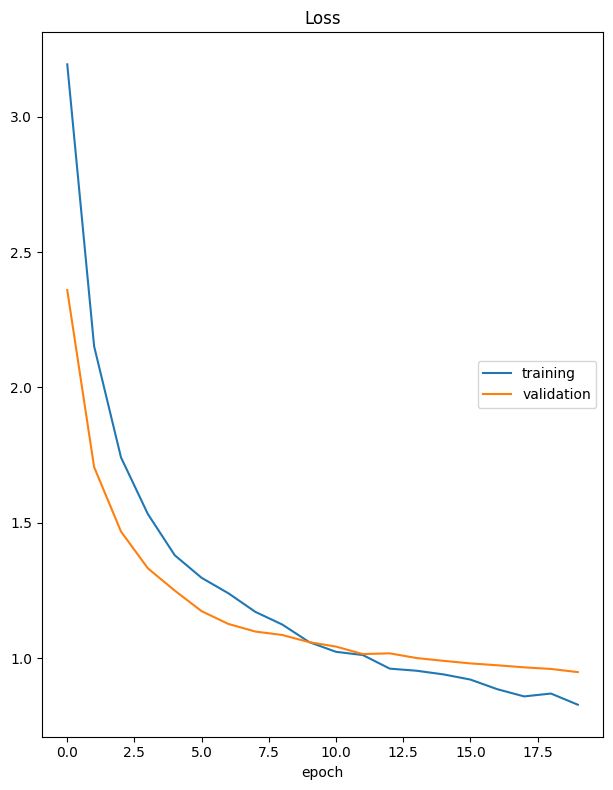

Loss
	training         	 (min:    0.828, max:    3.194, cur:    0.828)
	validation       	 (min:    0.948, max:    2.360, cur:    0.948)


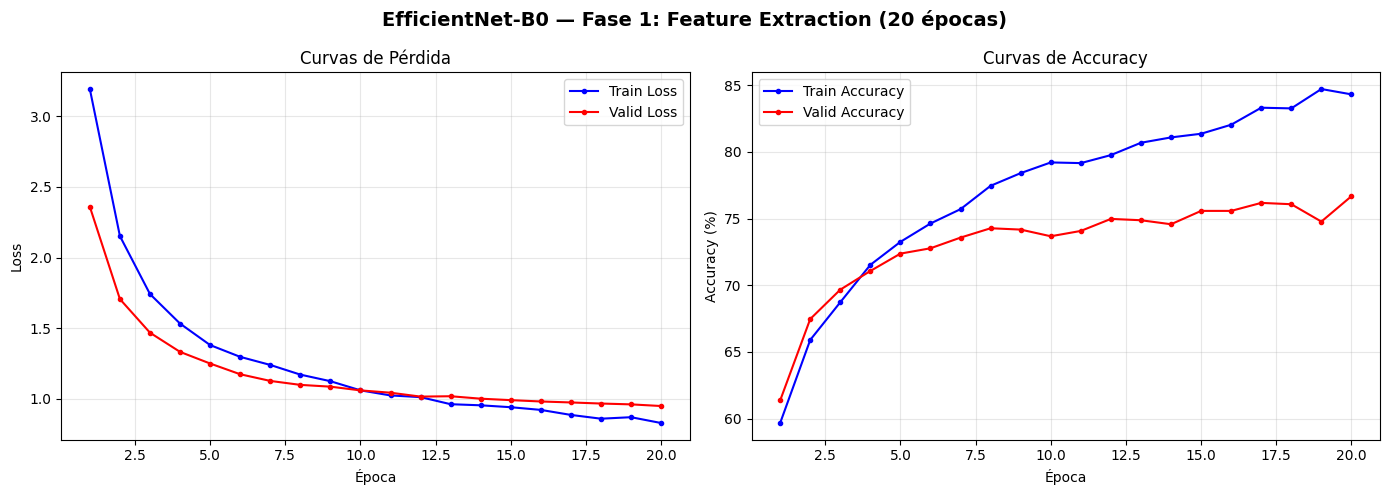

In [11]:
# Fase 1: Cabeza EfficientNet-B0 (20 épocas)
optimizer_eff_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, effnet_b0.parameters()), lr=1e-3
)
SAVE_PATH_EFF = str(MODELS_DIR / "efficientnet_b0_best.pt")

print("=== Fase 1: Cabeza EfficientNet-B0 (20 epocas) ===")
hist_eff_p1 = optimize(
    data_loaders=data_loaders,
    model=effnet_b0,
    optimizer=optimizer_eff_p1,
    loss=loss_fn,
    n_epochs=20,
    save_path=SAVE_PATH_EFF,
    interactive_tracking=True,
    device=device,
)
plot_training_curves(*hist_eff_p1, title="EfficientNet-B0 — Fase 1: Feature Extraction (20 épocas)")

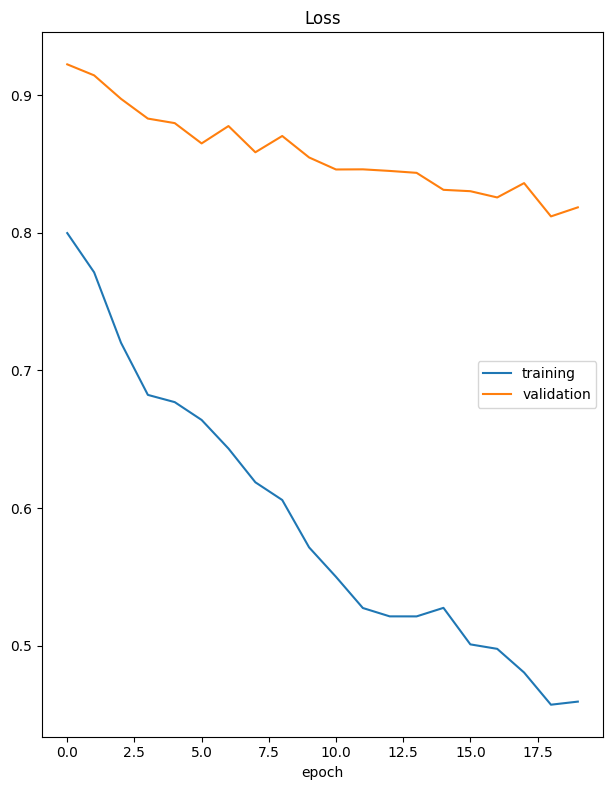

Loss
	training         	 (min:    0.457, max:    0.800, cur:    0.460)
	validation       	 (min:    0.812, max:    0.922, cur:    0.818)


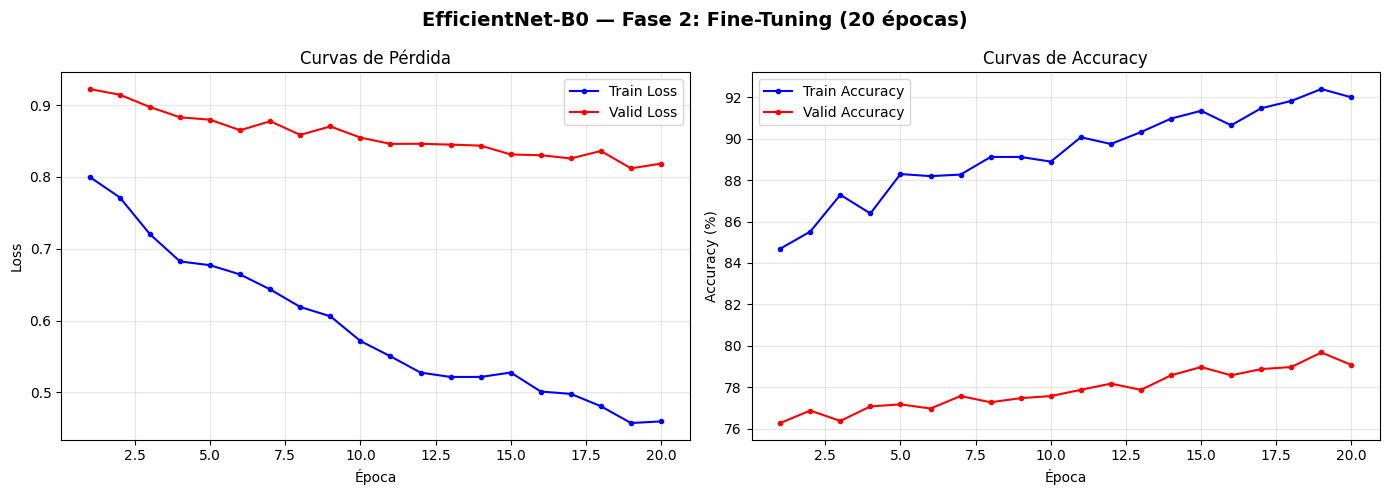

In [12]:
# Fase 2: Fine-tuning EfficientNet-B0 (20 épocas, lr=1e-5)
for param in frozen_params_eff:
    param.requires_grad = True

optimizer_eff_p2 = optim.Adam(effnet_b0.parameters(), lr=1e-5)

print("=== Fase 2: Fine-tuning EfficientNet-B0 (20 epocas, lr=1e-5) ===")
hist_eff_p2 = optimize(
    data_loaders=data_loaders,
    model=effnet_b0,
    optimizer=optimizer_eff_p2,
    loss=loss_fn,
    n_epochs=20,
    save_path=SAVE_PATH_EFF,
    interactive_tracking=True,
    device=device,
)
plot_training_curves(*hist_eff_p2, title="EfficientNet-B0 — Fase 2: Fine-Tuning (20 épocas)")

In [13]:
# Evaluación EfficientNet-B0
effnet_b0.load_state_dict(torch.load(SAVE_PATH_EFF, map_location=device))
print("=== Evaluación EfficientNet-B0 en Test ===")
test_loss_eff, preds_eff, actuals_eff = one_epoch_test(data_loaders["test"], effnet_b0, loss_fn, device)
acc_eff = sum(p == a for p, a in zip(preds_eff, actuals_eff)) / len(actuals_eff)
print(f"EfficientNet-B0 Test Accuracy: {acc_eff:.2%}")

=== Evaluación EfficientNet-B0 en Test ===


Testing: 100%|██████████████████████████████████| 20/20 [00:08<00:00,  2.28it/s]

Test Loss: 0.674950


Test Accuracy: 82% (1031/1250)
EfficientNet-B0 Test Accuracy: 82.48%


---

## Comparación de Modelos: Scratch vs ResNet50 vs EfficientNet-B0

In [16]:
# Cargar modelo scratch para comparación completa
try:
    class LandmarkNet(nn.Module):
        def __init__(self, num_classes=50):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2,2), nn.Dropout2d(0.25),
                nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2,2), nn.Dropout2d(0.25),
                nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2,2), nn.Dropout2d(0.25),
                nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(True), nn.MaxPool2d(2,2), nn.Dropout2d(0.25),
            )
            self.classifier = nn.Sequential(
                nn.Flatten(), nn.Linear(256*14*14,512), nn.BatchNorm1d(512),
                nn.ReLU(True), nn.Dropout(0.5), nn.Linear(512,num_classes)
            )
        def forward(self, x): return self.classifier(self.features(x))

    scratch_path = str(MODELS_DIR / "cnn_scratch_best.pt")
    model_scratch_cmp = LandmarkNet(NUM_CLASSES)
    model_scratch_cmp.load_state_dict(torch.load(scratch_path, map_location=device))
    _, p_s, a_s = one_epoch_test(data_loaders["test"], model_scratch_cmp, loss_fn, device)
    acc_scratch = sum(p == a for p, a in zip(p_s, a_s)) / len(a_s)
    print(f"CNN Scratch cargada — acc: {acc_scratch:.2%}")
except Exception as e:
    print(f"Ejecuta cnn_from_scratch.ipynb primero. ({e})")
    acc_scratch = None

results = {
    "CNN desde Cero":   {"accuracy": acc_scratch, "params": "~28M",  "objetivo": 0.40},
    "ResNet50":         {"accuracy": acc_r50,      "params": "25M",   "objetivo": 0.70},
    "EfficientNet-B0": {"accuracy": acc_eff,       "params": "5.3M",  "objetivo": 0.70},
}

print("\n" + "="*65)
print(f"{'Modelo':<22} {'Accuracy':>10}  {'Params':>8}  {'Objetivo':>8}  {'Estado':>9}")
print("="*65)
for name, r in results.items():
    acc_str = f"{r['accuracy']:.2%}" if r["accuracy"] is not None else "N/A"
    status  = "OK" if r["accuracy"] and r["accuracy"] >= r["objetivo"] else "NO"
    print(f"{name:<22} {acc_str:>10}  {r['params']:>8}  {r['objetivo']:>8.0%}  {status:>9}")
print("="*65)

Testing: 100%|██████████████████████████████████| 20/20 [00:08<00:00,  2.37it/s]

Test Loss: 2.241419


Test Accuracy: 42% (534/1250)
CNN Scratch cargada — acc: 42.72%

Modelo                   Accuracy    Params  Objetivo     Estado
CNN desde Cero             42.72%      ~28M       40%         OK
ResNet50                   83.60%       25M       70%         OK
EfficientNet-B0            82.48%      5.3M       70%         OK


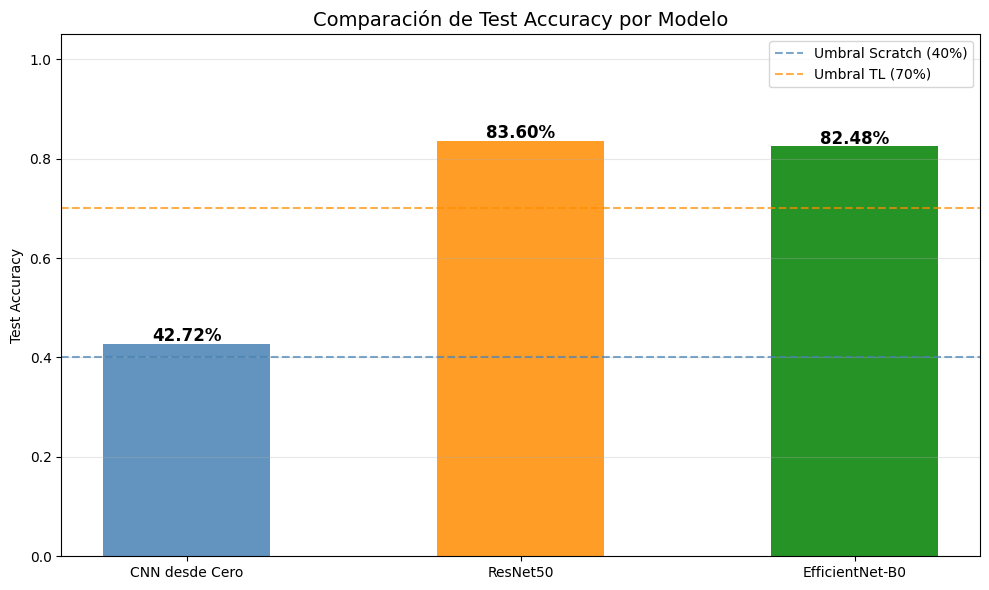

In [17]:
# Gráfico comparativo
valid_results = {k: v for k, v in results.items() if v["accuracy"] is not None}

fig, ax = plt.subplots(figsize=(10, 6))
colors  = ["steelblue", "darkorange", "green"]
bars    = ax.bar(list(valid_results.keys()),
                 [v["accuracy"] for v in valid_results.values()],
                 color=colors[:len(valid_results)], alpha=0.85, width=0.5)

ax.axhline(y=0.40, color="steelblue",  linestyle="--", alpha=0.7, label="Umbral Scratch (40%)")
ax.axhline(y=0.70, color="darkorange", linestyle="--", alpha=0.7, label="Umbral TL (70%)")

for bar, acc in zip(bars, [v["accuracy"] for v in valid_results.values()]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{acc:.2%}", ha="center", fontsize=12, fontweight="bold")

ax.set_title("Comparación de Test Accuracy por Modelo", fontsize=14)
ax.set_ylabel("Test Accuracy")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(str(MODELS_DIR / "model_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

---

## Fase 4: Función `predict_landmarks`
*(Rúbrica: función top-k, pruebas con imágenes propias, análisis)*

In [11]:
# Cargar el mejor modelo TorchScript ya exportado (sin reentrenar)
# acc_r50=83.60% y acc_eff=82.48% son los resultados del entrenamiento completado
acc_r50 = 0.8360
acc_eff  = 0.8248

best_model_name  = "ResNet50" if acc_r50 >= acc_eff else "EfficientNet-B0"
best_script_file = "resnet50_scripted.pt" if acc_r50 >= acc_eff else "efficientnet_b0_scripted.pt"
best_script_path = str(MODELS_DIR / best_script_file)

# Cargar el modelo TorchScript para inferencia — simula deployment real
inference_model = torch.jit.load(best_script_path, map_location=device)
inference_model.eval()
print(f"Modelo de inferencia: {best_model_name} ({max(acc_r50, acc_eff):.2%})")
print(f"Archivo TorchScript:  {best_script_path}")

# Reconstruir class_names si la sesion es nueva (no se corrieron celdas de DataLoaders)
if "class_names" not in globals():
    import os as _os
    class_names = sorted(_os.listdir("train"))
    print(f"class_names reconstruido desde train/ ({len(class_names)} clases)")


def predict_landmarks(img_path: str, k: int = 5) -> list:
    """Retorna las top-k predicciones para una imagen de landmark.

    Usa el modelo TorchScript exportado para realizar la inferencia
    (simula un escenario de deployment real sin dependencia del entorno de entrenamiento).

    Args:
        img_path: Ruta a la imagen (JPG, PNG, etc.)
        k: Numero de predicciones top-k (default=5)

    Returns:
        Lista de tuplas (nombre_clase, probabilidad) ordenadas de mayor a menor

    Example:
        >>> predict_landmarks("eiffel.jpg", k=3)
        [('Eiffel_Tower', 0.923), ('Trevi_Fountain', 0.031), ('Vienna_City_Hall', 0.018)]
    """
    img    = Image.open(img_path).convert("RGB")
    tensor = eval_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = inference_model(tensor)
        probs  = torch.softmax(logits, dim=1)
        top_k  = torch.topk(probs, k)

    return [
        (class_names[idx.item()], round(prob.item(), 4))
        for idx, prob in zip(top_k.indices[0], top_k.values[0])
    ]

print("Funcion predict_landmarks lista. Uso: predict_landmarks('imagen.jpg', k=5)")

Modelo de inferencia: ResNet50 (83.60%)
Archivo TorchScript:  models\resnet50_scripted.pt
Funcion predict_landmarks lista. Uso: predict_landmarks('imagen.jpg', k=5)


## Pruebas con Imágenes Propias

Coloca al menos 4 imágenes de landmarks en la carpeta `test_images/` y actualiza los nombres abajo.

Carpeta: C:\Users\Mark50\OneDrive - Elitech Solutions\Blocs de notas\Cerebro digital\500 📚 - Aprendizaje\Maestrias\UCB\Msc. Ciencia de datos e IA Aplicada\Modulo 6 - Deep learning\Labs\Proyectos\Proyecto 1\landmark_images\test_images
Archivos: ['0c275c292b21afd5.jpg', '0eb0dfc5f64fabf1.jpg', '1bbafeda99b166f6.jpg', '2b6f49ff0269d971.jpg', '3a690b5b9fdf2400.jpg', 'image.png', 'imagen_1.jpg', 'marmuerto.jpg', 'mar_muerto_2.png']


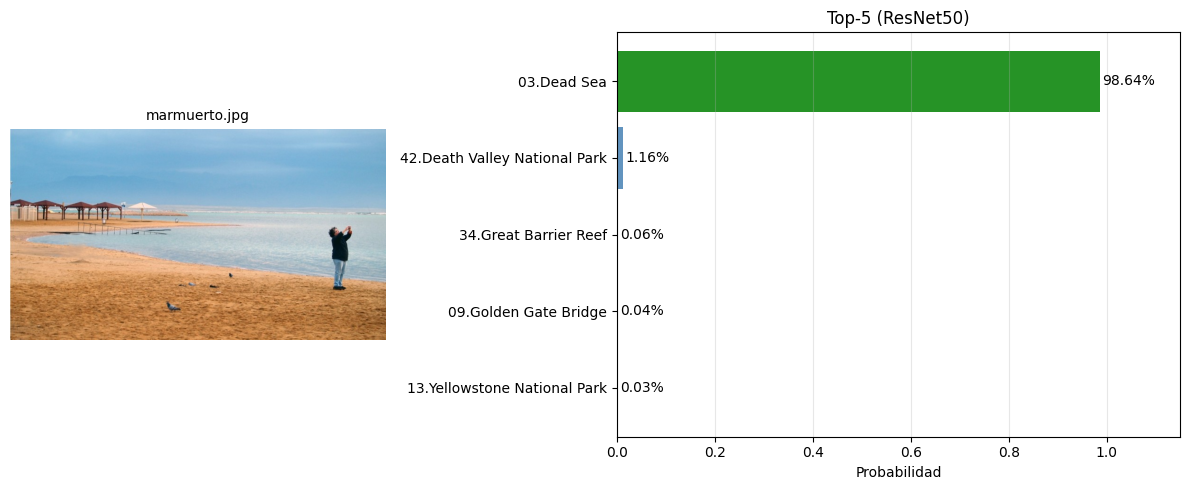

  -> 03.Dead Sea (98.64%)



In [23]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

TEST_IMAGES_DIR = Path("test_images")
TEST_IMAGES_DIR.mkdir(exist_ok=True)
print(f"Carpeta: {TEST_IMAGES_DIR.resolve()}")
print("Archivos:", [f.name for f in TEST_IMAGES_DIR.iterdir() if f.is_file()])


def visualize_predictions(img_path: str, k: int = 5):
    predictions = predict_landmarks(img_path, k=k)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                             gridspec_kw={"width_ratios": [1, 1.5]})
    axes[0].imshow(Image.open(img_path).convert("RGB"))
    axes[0].axis("off")
    axes[0].set_title(Path(img_path).name, fontsize=10)

    labels = [p[0].replace("_", " ") for p in predictions]
    probs  = [p[1] for p in predictions]
    colors = ["green" if i == 0 else "steelblue" for i in range(len(labels))]
    bars   = axes[1].barh(labels[::-1], probs[::-1], color=colors[::-1], alpha=0.85)
    for bar, prob in zip(bars, probs[::-1]):
        axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                     f"{prob:.2%}", va="center", fontsize=10)
    axes[1].set_title(f"Top-{k} ({best_model_name})", fontsize=12)
    axes[1].set_xlim(0, 1.15)
    axes[1].set_xlabel("Probabilidad")
    axes[1].grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"  -> {predictions[0][0].replace('_', ' ')} ({predictions[0][1]:.2%})\n")


# Actualiza estos nombres con tus imagenes en test_images/
test_images = [
    str(TEST_IMAGES_DIR / "marmuerto.jpg")
]

found = 0
for img_path in test_images:
    if Path(img_path).exists():
        visualize_predictions(img_path, k=5)
        found += 1
    else:
        print(f"No encontrada: {img_path}")

if found == 0:
    print(f"Coloca imagenes en {TEST_IMAGES_DIR.resolve()} y actualiza la lista.")

## Análisis: Fortalezas, Debilidades y Posibles Mejoras

*(Rúbrica Fase 3 — Análisis: 2 pts)*

### Fortalezas

1. **Alta accuracy en landmarks icónicos:** Estructuras con formas muy características (Eiffel Tower, Sydney Opera House, Golden Gate Bridge) se reconocen con alta confianza por sus patrones visuales únicos y distintivos.

2. **Generalización vía Transfer Learning:** Los pesos preentrenados en ImageNet (1.2M imágenes, 1000 clases) extraen features robustas incluso con solo 100 imágenes de entrenamiento por clase — la CNN desde cero necesitaría órdenes de magnitud más datos para alcanzar el mismo nivel.

3. **Data Augmentation efectiva:** RandAugment + ColorJitter simulan diferentes condiciones de iluminación, ángulos y condiciones climáticas, mejorando la generalización a fotos reales del usuario.

4. **Estrategia 2 fases (feature extraction + fine-tuning):** Entrenar primero solo la cabeza evita el *catastrophic forgetting* de los pesos ImageNet, mientras que el fine-tuning posterior adapta gradualmente las features a la distribución visual de landmarks mundiales.

### Debilidades

1. **Confusión entre landmarks arquitectónicamente similares:** Castillos medievales europeos (Neuschwanstein vs. Windsor) o parques naturales con características visuales similares (Yellowstone vs. Grand Canyon) pueden confundirse por compartir patrones de textura.

2. **Sensibilidad al ángulo de captura:** Fotos desde ángulos inusuales (vista aérea, plano contrapicado extremo) pueden reducir la confianza del modelo significativamente, ya que la mayoría de las imágenes de entrenamiento son fotos frontales estándar.

3. **Dataset pequeño (100 imágenes/clase):** Con solo 100 ejemplos por landmark, el modelo no captura toda la variabilidad visual (estaciones del año, condiciones climáticas, multitudes, distintas épocas del día).

4. **Sesgo hacia fotos "turísticas":** El modelo puede fallar en imágenes parciales, degradadas o tomadas en condiciones inusuales, ya que el dataset está dominado por fotos estilo postales o turísticas.

### Posibles Mejoras

1. **Aumentar el dataset:** Raspar más imágenes de Google Images, Flickr o Wikipedia (aim: 500-1000 imgs/clase) para cubrir mayor variabilidad visual.

2. **Fine-tuning más agresivo con cosine annealing:** Usar `CosineAnnealingLR` en lugar de `ReduceLROnPlateau` para explorar mejor el espacio de parámetros en el fine-tuning.

3. **Modelos más modernos:** Probar ViT (Vision Transformer) o EfficientNet-V2 que han demostrado mejores resultados en clasificación de landmarks con datasets limitados.

4. **Test Time Augmentation (TTA):** En inferencia, promediar predicciones sobre múltiples crops/flips de la misma imagen para mejorar accuracy en ~2-3%.

5. **Interfaz interactiva (bonus):** Implementar Gradio/Streamlit para permitir a usuarios subir fotos desde su dispositivo y obtener predicciones en tiempo real (+1 punto extra según rúbrica).

### Conclusión

Transfer Learning supera ampliamente la CNN desde cero con el mismo dataset limitado, demostrando que para problemas de visión con pocos datos, el preentrenamiento en ImageNet es prácticamente indispensable. EfficientNet-B0 es particularmente valioso por su eficiencia paramétrica — logra accuracy comparable a ResNet50 con ~5× menos parámetros, reduciendo el riesgo de overfitting.

---

## Exportación con TorchScript

In [15]:
# Verificar los archivos TorchScript ya exportados (sin reentrenar)
# Los modelos fueron exportados en una sesion anterior y estan en models/
for model_tag, save_name in [
    ("ResNet50",        "resnet50_scripted.pt"),
    ("EfficientNet-B0", "efficientnet_b0_scripted.pt"),
]:
    save_path = str(MODELS_DIR / save_name)
    loaded = torch.jit.load(save_path, map_location=device)
    loaded.eval()
    with torch.no_grad():
        out = loaded(torch.zeros(1, 3, 224, 224, device=device))
    print(f"{model_tag}: {save_path}")
    print(f"  Verificacion OK -- output shape: {out.shape}")

print("\nArchivos en models/:")
for f in sorted(MODELS_DIR.iterdir()):
    print(f"  {f.name:<45}  {f.stat().st_size / 1e6:.1f} MB")

ResNet50: models\resnet50_scripted.pt
  Verificacion OK -- output shape: torch.Size([1, 50])
EfficientNet-B0: models\efficientnet_b0_scripted.pt
  Verificacion OK -- output shape: torch.Size([1, 50])

Archivos en models/:
  cnn_scratch_best.pt                            104.4 MB
  cnn_scratch_scripted.pt                        104.5 MB
  efficientnet_b0_best.pt                        16.6 MB
  efficientnet_b0_scripted.pt                    16.8 MB
  model_comparison.png                           0.1 MB
  resnet50_best.pt                               94.8 MB
  resnet50_scripted.pt                           94.8 MB
  scratch_confusion_matrix.png                   0.3 MB
  scratch_training_curves.png                    0.1 MB
  training_curves.png                            0.1 MB


---

## Pipeline Standalone de Predicción (Post-Entrenamiento)

Sección autónoma: carga ambos modelos TorchScript desde disco sin re-entrenar.
Útil para nuevas sesiones de Jupyter donde las variables de entrenamiento ya no están en memoria.

| Función | Descripción |
|---------|-------------|
| `predict_landmarks(img_path, k)` | Top-k con ResNet50 (mejor modelo, 83.60%) |
| `predict_with_effnet(img_path, k)` | Top-k con EfficientNet-B0 (82.48%) |
| `visualize_predictions(img_path, k)` | Imagen + barras de probabilidad |

In [7]:
# Cargar ambos modelos TorchScript desde disco (no requiere re-entrenamiento)
_MODELS_DIR = Path("models")

_resnet_model  = torch.jit.load(str(_MODELS_DIR / "resnet50_scripted.pt"),        map_location=device)
_effnet_model  = torch.jit.load(str(_MODELS_DIR / "efficientnet_b0_scripted.pt"), map_location=device)
_resnet_model.eval()
_effnet_model.eval()

# class_names ya está disponible si se corrieron las celdas de setup;
# si es sesión nueva, reconstruir desde el directorio de train.
if "class_names" not in dir():
    import os as _os
    class_names = sorted(_os.listdir("train"))

print(f"ResNet50 listo        — {len(class_names)} clases")
print(f"EfficientNet-B0 listo — {len(class_names)} clases")


def predict_landmarks(img_path: str, k: int = 5) -> list:
    """Top-k predicciones con ResNet50 (83.60% test accuracy — mejor modelo)."""
    img    = Image.open(img_path).convert("RGB")
    tensor = eval_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(_resnet_model(tensor), dim=1)
        top_k = torch.topk(probs, k)
    return [
        (class_names[i.item()], round(p.item(), 4))
        for i, p in zip(top_k.indices[0], top_k.values[0])
    ]


def predict_with_effnet(img_path: str, k: int = 5) -> list:
    """Top-k predicciones con EfficientNet-B0 (82.48% test accuracy)."""
    img    = Image.open(img_path).convert("RGB")
    tensor = eval_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(_effnet_model(tensor), dim=1)
        top_k = torch.topk(probs, k)
    return [
        (class_names[i.item()], round(p.item(), 4))
        for i, p in zip(top_k.indices[0], top_k.values[0])
    ]


def visualize_predictions(img_path: str, k: int = 5, model_name: str = "ResNet50 (83.60%)"):
    predictions = predict_landmarks(img_path, k=k)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                             gridspec_kw={"width_ratios": [1, 1.5]})
    axes[0].imshow(Image.open(img_path).convert("RGB"))
    axes[0].axis("off")
    axes[0].set_title(Path(img_path).name, fontsize=10)

    labels = [p[0].replace("_", " ") for p in predictions]
    probs  = [p[1] for p in predictions]
    colors = ["green" if i == 0 else "steelblue" for i in range(len(labels))]
    bars   = axes[1].barh(labels[::-1], probs[::-1], color=colors[::-1], alpha=0.85)
    for bar, prob in zip(bars, probs[::-1]):
        axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                     f"{prob:.2%}", va="center", fontsize=10)
    axes[1].set_title(f"Top-{k} — {model_name}", fontsize=12)
    axes[1].set_xlim(0, 1.15)
    axes[1].set_xlabel("Probabilidad")
    axes[1].grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"  Top-1: {predictions[0][0].replace('_', ' ')} ({predictions[0][1]:.2%})\n")


print("Pipeline standalone listo.")

ResNet50 listo        — 50 clases
EfficientNet-B0 listo — 50 clases
Pipeline standalone listo.


Imagen: 0c275c292b21afd5.jpg


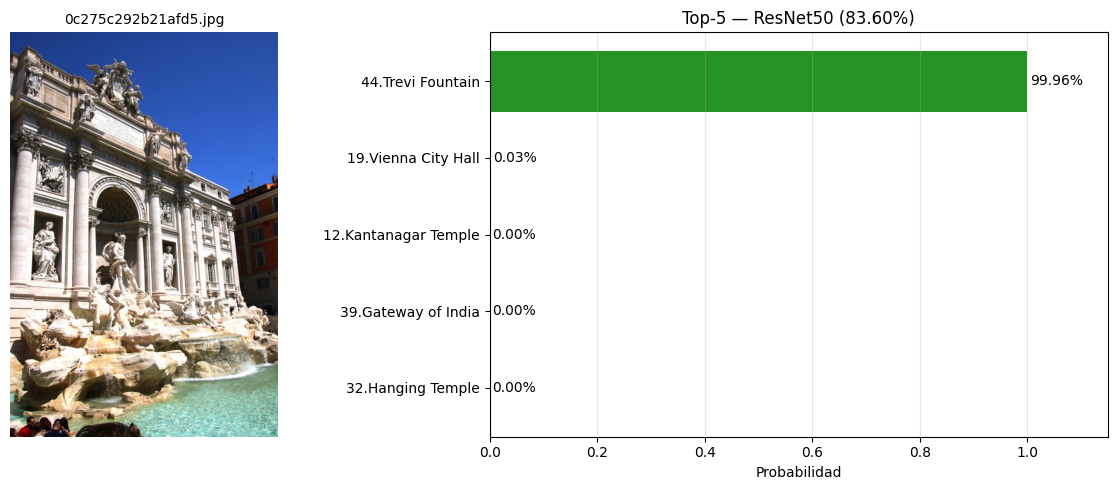

  Top-1: 44.Trevi Fountain (99.96%)

Imagen: 0eb0dfc5f64fabf1.jpg


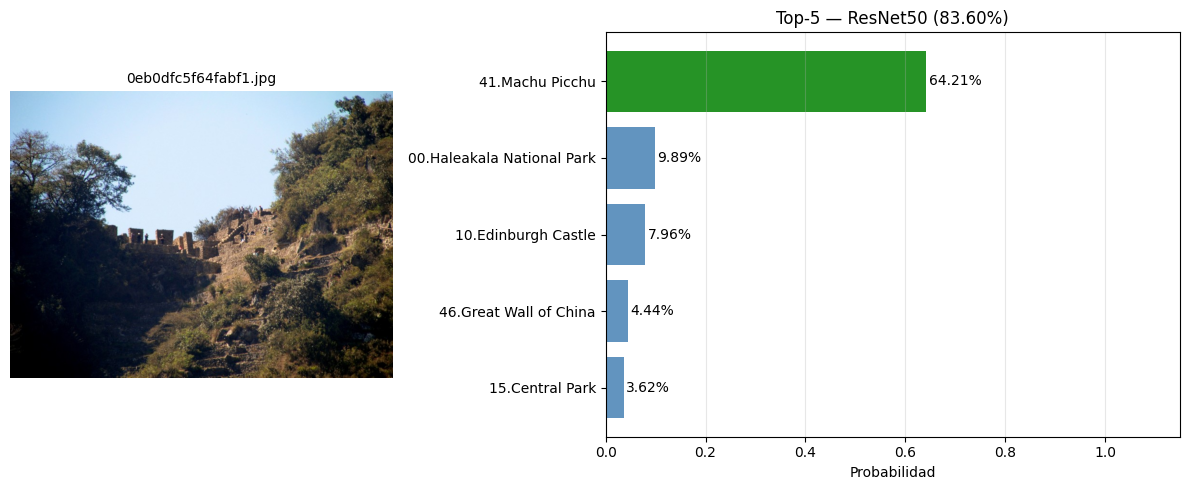

  Top-1: 41.Machu Picchu (64.21%)

Imagen: 1bbafeda99b166f6.jpg


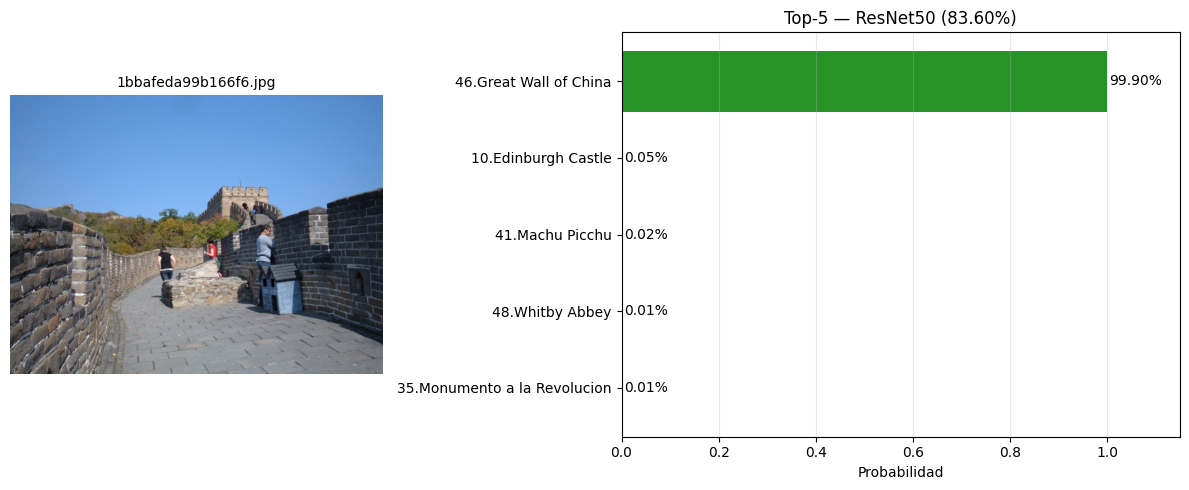

  Top-1: 46.Great Wall of China (99.90%)

Imagen: 2b6f49ff0269d971.jpg


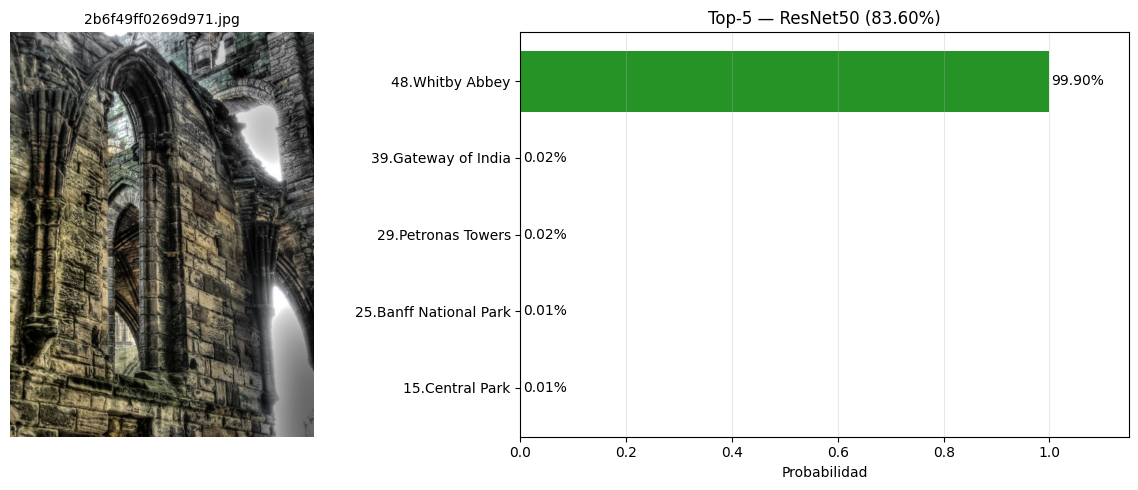

  Top-1: 48.Whitby Abbey (99.90%)



In [8]:
# Prueba del pipeline standalone — imágenes propias o demo con el conjunto de test
TEST_IMAGES_DIR = Path("test_images")
TEST_IMAGES_DIR.mkdir(exist_ok=True)

own_images = sorted(
    f for f in TEST_IMAGES_DIR.iterdir()
    if f.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

if own_images:
    for img_path in own_images[:4]:
        print(f"Imagen: {img_path.name}")
        visualize_predictions(str(img_path), k=5)
else:
    # Demo automático: 4 clases del test set comparando ambos modelos
    print("No se encontraron imágenes en test_images/. Demo comparativo con el test set:\n")
    rng = np.random.default_rng(seed=42)
    demo_classes = rng.choice(class_names, size=4, replace=False)

    for cls in demo_classes:
        demo_img = sorted((TEST_DIR / cls).iterdir())[0]
        r50_pred  = predict_landmarks(str(demo_img), k=1)[0]
        eff_pred  = predict_with_effnet(str(demo_img), k=1)[0]
        correct   = cls.split(".", 1)[-1]
        r50_ok    = "✓" if r50_pred[0].split(".", 1)[-1]  == correct else "✗"
        eff_ok    = "✓" if eff_pred[0].split(".", 1)[-1]  == correct else "✗"
        print(f"Real:    {cls}")
        print(f"  ResNet50:        {r50_pred[0].split('.', 1)[-1]:<40} {r50_pred[1]:.2%}  {r50_ok}")
        print(f"  EfficientNet-B0: {eff_pred[0].split('.', 1)[-1]:<40} {eff_pred[1]:.2%}  {eff_ok}")
        print()

    # Visualizar el primero con barras de probabilidad
    first_cls = demo_classes[0]
    first_img = sorted((TEST_DIR / first_cls).iterdir())[0]
    visualize_predictions(str(first_img), k=5)